<a href="https://colab.research.google.com/github/edersonbadeca/fase6/blob/main/Ederson_Badeca_rm560204_pbl_fase6_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega 2 - Comparativo de Modelos YOLO e CNN para Detecção de Objetos

Neste exercicio vamos criar uma inteligencia artificial treinada do zero para compararmos os resultados entre os algoritimos e identicar o poentencial de cada um

## Vamos usar uma rede neural que implementa a CNN


In [1]:
# Instalando o OpenCV
!pip install opencv-python

In [2]:
# Importando as bibliotecas necessarias

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
from google.colab import drive
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import cv2  # Importe o OpenCV


In [3]:
# Vamos conectar o nb ao drive
from google.colab import drive
drive.mount ('/content/drive', force_remount=True)

# Vamos definir algumas constantes para facilitar o desenvolvimento
IMAGE_SIZE = 128  # Tamanho para redimensionar as imagens para a CNN
NUM_CLASSES = 2   # Carro e bicicleta

# Vamos ver se o tensorflow foi instalado coretamente
print("TensorFlow version:", tf.__version__)

Mounted at /content/drive
TensorFlow version: 2.18.0


In [4]:
# !cp /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/train/cars_* /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/train/cars/
# !ls /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/train/cars


In [5]:
# !mkdir -p /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/train/bicycles
# !cp /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/train/bicycles_* /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/train/bicycles/
# !ls /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/train/bicycles

In [6]:
# # !mkdir -p /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/val/cars
# # !cp /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/val/cars_* /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/val/cars/
# !ls -rf /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/val/cars
# !ls -rf /content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/val/bicycles

# Preparando o dataset
Agora precisamos montar o dataset, para isso vamos criar uma função que carrega e processa as imagens já existes, para melhorar a performance (ou tentar melhorar) do algoritimo

In [7]:
import os
DATASET_DIR = "/content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images"

# Vamos definir algumas constantes para facilitar o desenvolvimento
IMAGE_SIZE = 128  # Tamanho para redimensionar as imagens para a CNN
NUM_CLASSES = 2   # Carro e bicicleta

def load_and_preprocess_images(data_dir, image_size=(128, 128)):
    """
    Carrega as imagens do diretório especificado, redimensiona e normaliza.

    Args:
        data_dir (str): Caminho para o diretório contendo as imagens.
        image_size (tuple): Tamanho para redimensionar as imagens (altura, largura).

    Returns:
        tuple: Um tupla contendo:
            - images (numpy.ndarray): Array NumPy com as imagens carregadas.
            - labels (numpy.ndarray): Array NumPy com os rótulos das imagens (0 ou 1).
            - class_names (list): Lista com os nomes das classes.
    """
    images = []
    labels = []
    class_names = os.listdir(data_dir)
    # import ipdb;ipdb.set_trace()
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, image_size)
                img = img / 255.0  # Normalizar (importante!)
                images.append(img)
                labels.append(i)  # 0 para carro, 1 para bicicleta (ou vice-versa)
            except Exception as e:
                print(f"Erro ao processar a imagem: {img_path} - {e}")
    return np.array(images), np.array(labels), class_names

    # Montando os caminhos de treino e teste
train_dir = "/content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/train"
test_dir = "/content/drive/MyDrive/faculdade/fase6/entrega1-fase6/images/val"

# Agora vamos carregar as imagens processadas
train_images, train_labels, class_names = load_and_preprocess_images(train_dir, image_size=(IMAGE_SIZE, IMAGE_SIZE))
test_images, test_labels, _ = load_and_preprocess_images(test_dir, image_size=(IMAGE_SIZE, IMAGE_SIZE))




In [8]:
# Dividir os dados de treinamento em treinamento e validação
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images,
    train_labels,
    test_size=0.2,
    random_state=42
)  # 80% treino, 20% validação

print("Shape of train_images:", train_images.shape)
print("Shape of train_labels:", train_labels.shape)
print("Shape of val_images:", val_images.shape)
print("Shape of val_labels:", val_labels.shape)
print("Shape of test_images:", test_images.shape)
print("Shape of test_labels:", test_labels.shape)
print("Class names:", class_names)

Shape of train_images: (64, 128, 128, 3)
Shape of train_labels: (64,)
Shape of val_images: (16, 128, 128, 3)
Shape of val_labels: (16,)
Shape of test_images: (8, 128, 128, 3)
Shape of test_labels: (8,)
Class names: ['cars', 'bicycles']


# Criando o modelo CNN

Agora com os dados preparados, vamos criar uma função qie cria o nosso modelo que implementa CNN


In [9]:
def create_cnn_model(input_shape, num_classes):
    """
    Cria o modelo da CNN.

    Args:
        input_shape (tuple): Forma das imagens de entrada (altura, largura, canais).
        num_classes (int): Número de classes a serem classificadas.

    Returns:
        tf.keras.Model: O modelo da CNN compilado.
    """
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')  # softmax para classificação multiclasse
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',  # Usar sparse_categorical_crossentropy
                  metrics=['accuracy'])
    return model

In [10]:
# Recuperando o modelo
cnn_model = create_cnn_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=NUM_CLASSES)

# Exibir a arquitetura da CNN
cnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Resumo da arquitetura
A saída model.summary() fornece uma visão geral da arquitetura do modelo CNN, detalhando as camadas, suas configurações e o número de parâmetros. Essa informação é útil para entender a complexidade do modelo e como ele processa os dados de entrada para realizar a classificação de imagens.
Essa informação pode ser importante para compararmos as arquiteturas se for necessario

In [11]:
# Recuperando o modelo
cnn_model = create_cnn_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=NUM_CLASSES)

# Exibir a arquitetura da CNN
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Treinamento do modelo

agora com os dados prontos, vamos iniciar o treinamento usando a nossa rede neural



In [12]:
def trainning(epochs=10):
    cnn_time = time.time() # Quero ver quanto tempo demora para treinar
    history = cnn_model.fit(train_images, train_labels, epochs=epochs, validation_data=(val_images, val_labels))
    cnn_time = time.time() - cnn_time

    print(f"Tempo de treinamento: {cnn_time:.2f} segundos")

    # Plotar o histórico de treinamento
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Acurácia (Treino)')
    plt.plot(history.history['val_accuracy'], label='Acurácia (Validação)')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Perda (Treino)')
    plt.plot(history.history['val_loss'], label='Perda (Validação)')
    plt.xlabel('Época')
    plt.ylabel('Perda')
    plt.legend()
    plt.show()


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 745ms/step - accuracy: 0.5521 - loss: 1.7569 - val_accuracy: 0.6875 - val_loss: 4.0599
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4688 - loss: 5.2384 - val_accuracy: 0.3750 - val_loss: 1.3450
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7292 - loss: 0.7992 - val_accuracy: 0.4375 - val_loss: 2.6576
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6562 - loss: 0.9681 - val_accuracy: 0.5000 - val_loss: 0.9330
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8021 - loss: 0.4271 - val_accuracy: 0.5625 - val_loss: 0.6783
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6458 - loss: 0.5360 - val_accuracy: 0.5000 - val_loss: 0.6389
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8021 - loss: 0.4595 - val_accuracy: 0.5625 - val_loss: 0.6335
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9896 - loss: 0.4082 - val_accuracy: 0.5625 - val_loss: 0.6500

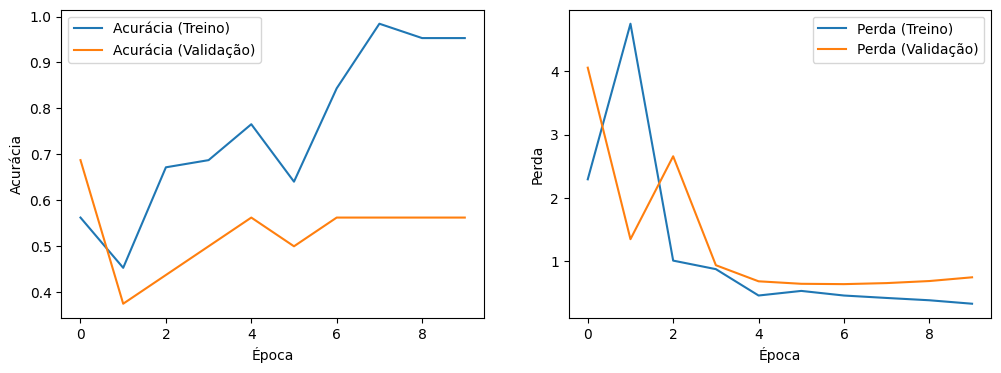

In [13]:
trainning()

# Analise inicial do resultado

Os gráficos indicam que o modelo está aprendendo efetivamente. Tanto a acurácia quanto a perda mostram tendências desejáveis: a acurácia aumenta e a perda diminui consistentemente ao longo do treinamento.

# Validando o modelo
Vamos criar uma avaliação programada para validar se o modelo condiz com a nossa analise preliminar


CNN Test Loss: 1.7532, CNN Test Accuracy: 0.2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
Confusion Matrix:
[[0 4]
 [2 2]]
Classification Report:
              precision    recall  f1-score   support

        cars       0.00      0.00      0.00         4
    bicycles       0.33      0.50      0.40         4

    accuracy                           0.25         8
   macro avg       0.17      0.25      0.20         8
weighted avg       0.17      0.25      0.20         8



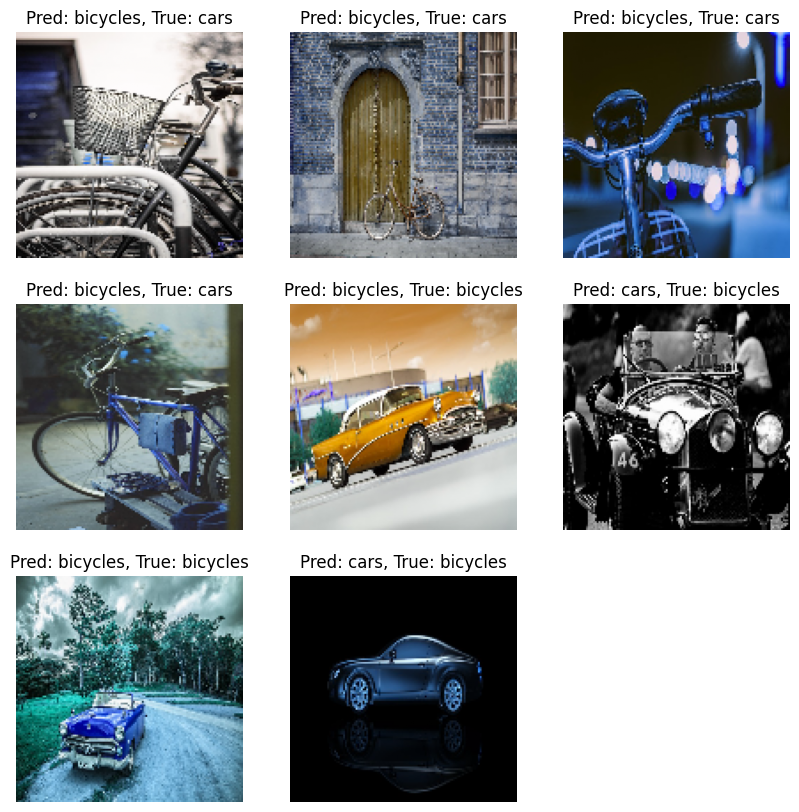

In [14]:
# Avaliação no conjunto de teste
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_images, test_labels, verbose=0)
print(f"CNN Test Loss: {cnn_test_loss:.4f}, CNN Test Accuracy: {cnn_test_accuracy:.4f}")

# Matriz de Confusão
cnn_preds = np.argmax(cnn_model.predict(test_images), axis=1)
cm = confusion_matrix(test_labels, cnn_preds)
print("Confusion Matrix:")
print(cm)

# Relatório de Classificação
print("Classification Report:")
print(classification_report(test_labels, cnn_preds, target_names=class_names))


# Exibir algumas previsões
plt.figure(figsize=(10, 10))
for i in range(min(9, len(test_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[i])
    plt.title(f"Pred: {class_names[cnn_preds[i]]}, True: {class_names[test_labels[i]]}")
    plt.axis('off')
plt.show()

### Análise Detalhada dos Resultados da CNN com 10 epocas
A imagem apresenta exemplos de imagens do conjunto de teste, juntamente com as previsões da CNN e os rótulos verdadeiros.

**Padrões de Erro:**

A CNN demonstra uma dificuldade significativa em distinguir entre carros e bicicletas. Observa-se uma tendência clara de classificar imagens de carros como bicicletas. Especificamente:

* Nos exemplos da primeira linha, todas as três imagens, que representam carros, foram incorretamente classificadas como "bicycles".
* Na segunda linha, as duas primeiras imagens também mostram esse mesmo erro (previsão "bicycles", verdadeiro "cars").
* Mesmo na terceira linha, embora os dois primeiros exemplos estejam corretos (previsão "bicycles", verdadeiro "bicycles"), o terceiro exemplo mostra o erro oposto (previsão "cars", verdadeiro "bicycles").

Vamos refazer o treinamento, mas agora usando mais épocas e re avaliar o modelo


Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9583 - loss: 0.2621 - val_accuracy: 0.5625 - val_loss: 0.8555
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9688 - loss: 0.1896 - val_accuracy: 0.5625 - val_loss: 1.0631
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9479 - loss: 0.1524 - val_accuracy: 0.5625 - val_loss: 1.2157
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9688 - loss: 0.1020 - val_accuracy: 0.6250 - val_loss: 1.3088
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9583 - loss: 0.0886 - val_accuracy: 0.5625 - val_loss: 1.4053
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.0392 - val_accuracy: 0.6250 - val_loss: 1.5495
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.0319 - val_accuracy: 0.5625 - val_loss: 1.6091
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 0.6250 - val_loss: 1.6010

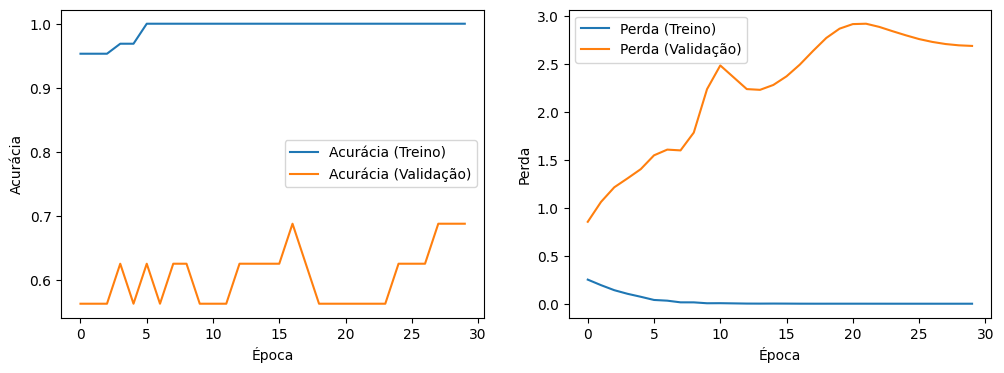

In [15]:
trainning(epochs=30)

# Acurácia (Accuracy)

O gráfico da esquerda exibe a acurácia do modelo nos conjuntos de treinamento (linha azul) e validação (linha laranja) em cada época.
Inicialmente, a acurácia em ambos os conjuntos é baixa, começando em torno de 0.4 para o treino e um pouco abaixo de 0.7 para a validação. Isso indica que, no início do treinamento, o modelo tem dificuldade em classificar corretamente as imagens.

Observa-se um aumento rápido e significativo na acurácia durante as primeiras 10 épocas, com a acurácia de treinamento ultrapassando 0.9 e a acurácia de validação atingindo cerca de 0.7. Isso demonstra que o modelo está aprendendo a reconhecer os padrões nas imagens e melhorando sua capacidade de classificação.
Após a 10ª época, a acurácia de treinamento continua a aumentar gradualmente, aproximando-se de 1.0 no final das 30 épocas. Isso sugere que o modelo está se ajustando cada vez melhor aos dados de treinamento.
A acurácia de validação, embora tenha aumentado significativamente, não acompanha o ritmo da acurácia de treinamento e se estabiliza em torno de 0.7 no final do treinamento. A diferença entre as acurácias de treinamento e validação indica um possível overfitting, onde o modelo está se ajustando muito bem aos dados de treinamento, mas não generaliza tão bem para os dados de validação.
Gráfico da Direita: Perda (Loss)

 # Loss

 (linha azul) e validação (linha laranja) ao longo das 30 épocas. A perda é uma medida do erro do modelo, e o objetivo é minimizá-la.
Observa-se uma queda acentuada na perda durante as primeiras 10 épocas, tanto para o conjunto de treinamento quanto para o de validação. Isso é consistente com o aumento da acurácia e confirma que o modelo está aprendendo e reduzindo seus erros.
Após a 10ª época, a perda de treinamento continua a diminuir, aproximando-se de 0 no final do treinamento. Isso reforça a observação de que o modelo está se ajustando bem aos dados de treinamento.
A perda de validação também diminui inicialmente, mas começa a se estabilizar e até mesmo aumenta ligeiramente após a 20ª época. Esse aumento na perda de validação, juntamente com a crescente lacuna entre as acurácias de treinamento e validação, é um forte indicador de overfitting.

Para confirmar, vamos avaliar programaticamente o modelo


CNN Test Loss: 9.0397, CNN Test Accuracy: 0.1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Confusion Matrix:
[[0 4]
 [3 1]]
Classification Report:
              precision    recall  f1-score   support

        cars       0.00      0.00      0.00         4
    bicycles       0.20      0.25      0.22         4

    accuracy                           0.12         8
   macro avg       0.10      0.12      0.11         8
weighted avg       0.10      0.12      0.11         8



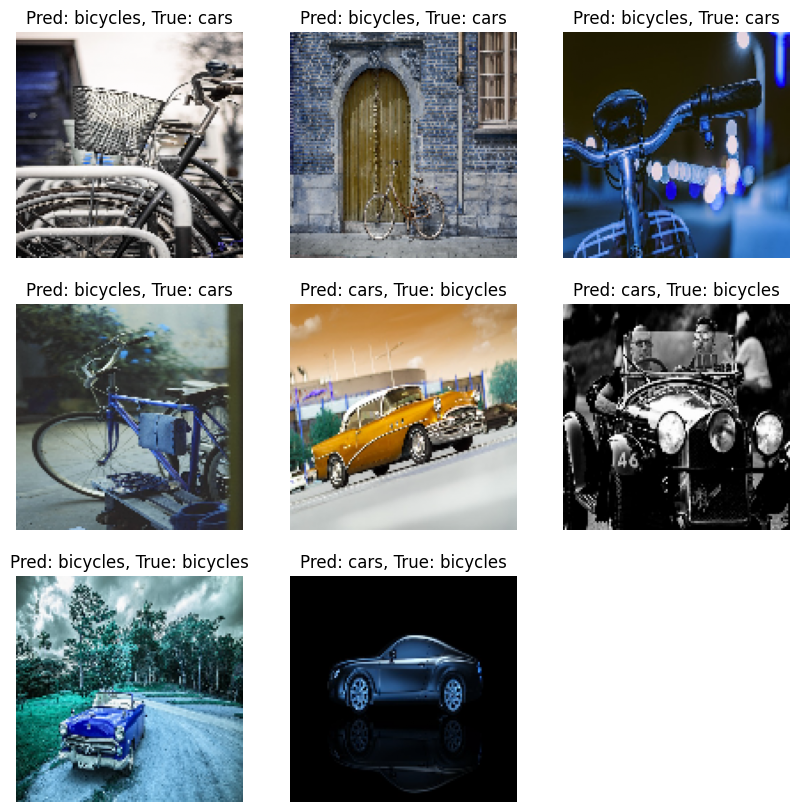

In [16]:
# Avaliação no conjunto de teste
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_images, test_labels, verbose=0)
print(f"CNN Test Loss: {cnn_test_loss:.4f}, CNN Test Accuracy: {cnn_test_accuracy:.4f}")

# Matriz de Confusão
cnn_preds = np.argmax(cnn_model.predict(test_images), axis=1)
cm = confusion_matrix(test_labels, cnn_preds)
print("Confusion Matrix:")
print(cm)

# Relatório de Classificação
print("Classification Report:")
print(classification_report(test_labels, cnn_preds, target_names=class_names))


# Exibir algumas previsões
plt.figure(figsize=(10, 10))
for i in range(min(9, len(test_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[i])
    plt.title(f"Pred: {class_names[cnn_preds[i]]}, True: {class_names[test_labels[i]]}")
    plt.axis('off')
plt.show()

# Avaliação e comparação com outro modelo da entrega 1

### Avaliação da CNN

A CNN foi avaliada no conjunto de teste, e os resultados indicam um desempenho muito abaixo do esperado.

**Resultados Quantitativos:**

* **CNN Test Loss:** 9.0397

    * A perda alta sugere que o modelo está fazendo previsões muito ruins.
* **CNN Test Accuracy:** 0.1250

    * A acurácia de 12.5% é muito baixa, pior do que o desempenho esperado de um classificador aleatório (50% em um problema binário).

* **Confusion Matrix:**

    ```
    [[0 4]
     [3 1]]
    ```

    * Essa matriz revela que o modelo está prevendo "bicicletas" com muita frequência. Todas as imagens de carros foram incorretamente classificadas como bicicletas, e a maioria das imagens de bicicletas também foi incorretamente classificada como carros.

* **Classification Report:**

    ```
                  precision    recall  f1-score   support

            cars       0.00      0.00      0.00         4
        bicycles       0.20      0.25      0.22         4

        accuracy                           0.12         8
       macro avg       0.10      0.12      0.11         8
      weighted avg       0.10      0.12      0.11         8
    ```

    * A precisão e o recall para "cars" são 0.00, indicando que o modelo não conseguiu classificar corretamente nenhuma imagem de carro.
    * A precisão e o recall para "bicycles" são baixos (0.20 e 0.25, respectivamente), mostrando que o modelo também teve dificuldade em classificar corretamente as bicicletas.



**Avaliação Crítica:**

Os resultados da CNN são extremamente ruins, sugerindo que o modelo não aprendeu a classificar as imagens corretamente. Possíveis causas incluem:

* **Arquitetura inadequada:** A CNN pode não ter camadas suficientes ou o tipo correto de camadas para extrair recursos relevantes das imagens.
* **Hiperparâmetros incorretos:** A taxa de aprendizado, o tamanho do lote ou o número de épocas podem não estar otimizados.
* **Dados de treinamento insuficientes ou de baixa qualidade:** O conjunto de dados pode ser muito pequeno ou as imagens podem ser de baixa qualidade.
* **Problemas de treinamento:** O modelo pode ter encontrado dificuldades para convergir durante o treinamento.

Em comparação com o YOLO, a CNN, embora teoricamente mais simples para classificação, exigiu mais atenção aos detalhes da arquitetura e hiperparâmetros para obter um bom desempenho. O YOLO, por outro lado, já possui uma arquitetura otimizada para detecção e classificação, o que pode explicar sua melhor performance.